In [1]:
# Librerias externas.
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

# Librerías propias
from dgst.utils.loader import *
from dgst.utils.processor import *
from dgst.utils.features import *
from dgst.utils.fuser import *
from dgst.utils.descriptors import *
from dgst.utils.matcher import *
from dgst.utils.hog_classifier import *

In [2]:
# Función para mostrar las imágenes en una cuadrícula
import numpy as np
import cv2 as cv

def plot_images(images, titles=None, grid_shape=(3, 4), figsize=None):
    if figsize is None:
        figsize = (grid_shape[1]*3, grid_shape[0]*2)

    fig, axes = plt.subplots(*grid_shape, figsize=figsize)

    # Normalizar `axes` a un iterador plano
    if isinstance(axes, np.ndarray):
        iter_axes = axes.flat
    else:
        # Cuando subplots devuelve un solo Axes (no array)
        iter_axes = iter([axes])

    for i, ax in enumerate(iter_axes):
        if i >= len(images):
            ax.axis('off')
            continue

        image = images[i]
        # Si es un objeto con get_image(), usarlo
        if not isinstance(image, np.ndarray) and hasattr(image, 'get_image'):
            try:
                image = image.get_image()
            except Exception:
                image = None

        if image is None:
            ax.text(0.5, 0.5, 'No image', ha='center', va='center')
        else:
            # Mostrar según dimensiones
            if isinstance(image, np.ndarray):
                if image.ndim == 2:
                    ax.imshow(image, cmap='gray')
                elif image.ndim == 3:
                    # Intentar convertir BGR->RGB si procede
                    try:
                        ax.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
                    except Exception:
                        ax.imshow(image)
                else:
                    ax.imshow(image)
            else:
                try:
                    ax.imshow(image)
                except Exception:
                    ax.text(0.5, 0.5, 'Cannot display image', ha='center', va='center')

        # Títulos
        if titles and i < len(titles):
            ax.set_title(str(titles[i]))
        else:
            ax.set_title(f'Image {i}')

        ax.axis('off')

    plt.tight_layout()
    plt.show()


# Función para mostrar las imágenes en una cuadrícula intercalando imágenes de diferentes listas
def intercalate_images(images_matrix, titles=None, grid_shape=(3, 4), figsize=None):
   
    intercalated_images = []
    intercalated_titles = []
    n_lists = len(images_matrix)
    if n_lists == 0:
        return
    n_images = len(images_matrix[0])
    idx = 0

    for i in range(n_images):
        for j in range(n_lists):
            prefix = titles[j] if (titles and j < len(titles)) else f'List{j}_'
            intercalated_titles.append(f"{prefix}{idx}")
            intercalated_images.append(images_matrix[j][i])
        idx += 1

    # Ajustar grid automáticamente si es necesario
    total = len(intercalated_images)
    rows, cols = grid_shape
    if rows * cols < total:
        # expandir filas para ajustarse
        rows = int(np.ceil(total / cols))
        grid_shape = (rows, cols)

    plot_images(intercalated_images, intercalated_titles, grid_shape, figsize)

In [3]:

classifier = HOGClassifier(
    data_path='images/bt3/hog',
    train_ratio=0.8,
    patch_size=(64, 64),
    hog_method=HOGMethod.SKIMAGE,
    random_seed=42,
)

In [4]:

n_train, n_test = classifier.load_and_split()
print(f"Training images: {n_train}, Test images: {n_test}")

Training images: 1600, Test images: 401


In [5]:
train_metrics = classifier.train(
    auto_balance_negatives=True,
    balance_ratio=1.0,
    force_retrain=False,
)

Loading image from images/bt3/hog/000795/camera_front_blur/000795_india_2021-04-17T10:44:01.107098Z.jpg
Loading image from images/bt3/hog/001792/camera_front_blur/001792_india_2021-05-04T15:49:12.772107Z.jpg
Loading image from images/bt3/hog/000478/camera_front_blur/000478_golf_2021-04-27T11:30:25.107248Z.jpg
Loading image from images/bt3/hog/000807/camera_front_blur/000807_golf_2021-04-27T09:09:19.105551Z.jpg
Loading image from images/bt3/hog/001614/camera_front_blur/001614_india_2021-04-29T14:04:25.447997Z.jpg
Loading image from images/bt3/hog/001787/camera_front_blur/001787_india_2021-04-20T06:55:29.777095Z.jpg
Loading image from images/bt3/hog/001805/camera_front_blur/001805_india_2021-04-18T17:16:42.665231Z.jpg
Loading image from images/bt3/hog/001433/camera_front_blur/001433_india_2021-04-18T16:16:42.337292Z.jpg
Loading image from images/bt3/hog/000083/camera_front_blur/000083_india_2021-04-29T13:12:06.226118Z.jpg
Loading image from images/bt3/hog/001957/camera_front_blur/001957_

In [6]:
print(f"Acc: {train_metrics.accuracy:.3f}, F1: {train_metrics.f1:.3f}")
print(f"Recall: {train_metrics.recall:.3f}, Precision: {train_metrics.precision:.3f}")

Acc: 0.722, F1: 0.712
Recall: 0.795, Precision: 0.645


In [30]:
eval_t = classifier.evaluate(negatives_per_image=20)

Loading image from images/bt3/hog/000164/camera_front_blur/000164_india_2021-04-14T11:39:27.995972Z.jpg
Loading image from images/bt3/hog/001040/camera_front_blur/001040_bravo_2021-06-08T19:12:55.781811Z.jpg
Loading image from images/bt3/hog/000116/camera_front_blur/000116_india_2021-04-13T12:04:08.337637Z.jpg
Loading image from images/bt3/hog/000322/camera_front_blur/000322_golf_2021-04-24T07:19:33.224542Z.jpg
Loading image from images/bt3/hog/001087/camera_front_blur/001087_india_2021-04-29T08:10:21.776727Z.jpg
Loading image from images/bt3/hog/001029/camera_front_blur/001029_golf_2021-04-27T11:03:25.113643Z.jpg
Loading image from images/bt3/hog/000976/camera_front_blur/000976_india_2021-04-18T15:53:12.447429Z.jpg
Loading image from images/bt3/hog/001196/camera_front_blur/001196_golf_2021-05-04T16:21:32.221824Z.jpg
Loading image from images/bt3/hog/000102/camera_front_blur/000102_golf_2021-04-28T17:53:28.549948Z.jpg
Loading image from images/bt3/hog/000117/camera_front_blur/000117_in

In [31]:
print(f"\n=== Patch Classification Metrics ===")
print(f"Accuracy:  {eval_t.accuracy:.4f}")
print(f"Precision: {eval_t.precision:.4f}")
print(f"Recall:    {eval_t.recall:.4f}")
print(f"F1-Score:  {eval_t.f1:.4f}")


=== Patch Classification Metrics ===
Accuracy:  0.7547
Precision: 0.8369
Recall:    0.7964
F1-Score:  0.8161


In [7]:
detection_metrics = classifier.evaluate_detections(
    stride=16,
    score_threshold=0.5,
    intersection_threshold=0.3,
    max_images=25,
    n_jobs=5,
)

Loading image from images/bt3/hog/000947/camera_front_blur/000947_india_2021-04-29T10:57:16.883844Z.jpg
Loading image from images/bt3/hog/001813/camera_front_blur/001813_india_2021-05-02T08:06:58.217252Z.jpg
Loading image from images/bt3/hog/000476/camera_front_blur/000476_india_2021-04-14T11:56:38.446723Z.jpg
Loading image from images/bt3/hog/001672/camera_front_blur/001672_india_2020-10-30T06:35:37.002863Z.jpg
Loading image from images/bt3/hog/000433/camera_front_blur/000433_golf_2021-04-28T17:54:21.550969Z.jpg
Loading image from images/bt3/hog/000247/camera_front_blur/000247_golf_2021-04-27T10:58:38.108810Z.jpg
Loading image from images/bt3/hog/000014/camera_front_blur/000014_india_2021-04-18T15:57:58.885517Z.jpg
Loading image from images/bt3/hog/000824/camera_front_blur/000824_golf_2021-04-27T10:55:57.772789Z.jpg
Loading image from images/bt3/hog/001232/camera_front_blur/001232_india_2021-04-24T11:03:32.888200Z.jpg
Loading image from images/bt3/hog/000200/camera_front_blur/000200_i

In [8]:
print(f"\n=== Detection Metrics ===")
print(f"TP: {detection_metrics.true_positives}, FP: {detection_metrics.false_positives}")
print(f"TN: {detection_metrics.true_negatives}, FN: {detection_metrics.false_negatives}")
print(f"")
print(f"Hit Rate:    {detection_metrics.hit_rate:.4f} (% correct)")
print(f"GT Coverage: {detection_metrics.gt_coverage:.4f} (% of GTs found)")
print(f"Accuracy:    {detection_metrics.accuracy:.4f}")
print(f"Precision:   {detection_metrics.precision:.4f}")
print(f"Recall:      {detection_metrics.recall:.4f}")
print(f"F1:          {detection_metrics.f1:.4f}")
print(f"")
print(f"GTs: {detection_metrics.num_gt_detected}/{detection_metrics.num_ground_truth}")
print(f"Windows: {detection_metrics.num_detections}/{detection_metrics.num_windows} positive")


=== Detection Metrics ===
TP: 1023, FP: 58095
TN: 718573, FN: 4409

Hit Rate:    0.9201 (% correct)
GT Coverage: 0.1090 (% of GTs found)
Accuracy:    0.9201
Precision:   0.0173
Recall:      0.1883
F1:          0.0317

GTs: 121/1110
Windows: 59118/782100 positive


Loading image from images/bt3/hog/000322/camera_front_blur/000322_golf_2021-04-24T07:19:33.224542Z.jpg


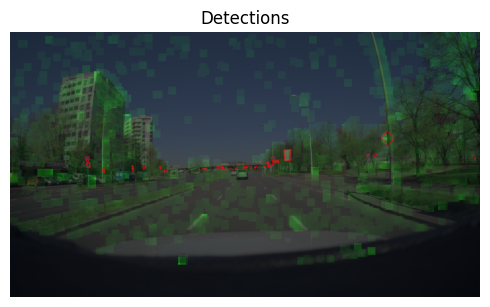

Loading image from images/bt3/hog/001087/camera_front_blur/001087_india_2021-04-29T08:10:21.776727Z.jpg


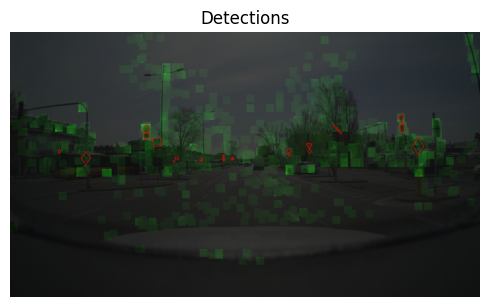

Loading image from images/bt3/hog/001531/camera_front_blur/001531_golf_2021-10-11T17:56:35.217183Z.jpg


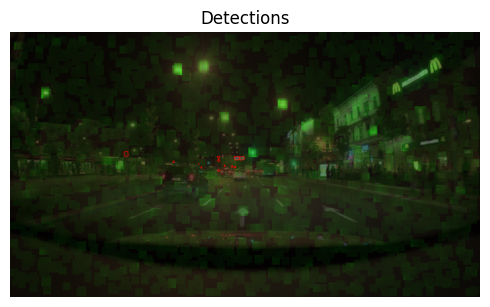

Loading image from images/bt3/hog/001110/camera_front_blur/001110_india_2021-05-01T07:54:06.886991Z.jpg


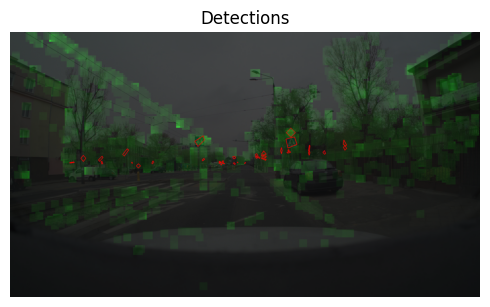

Loading image from images/bt3/hog/001506/camera_front_blur/001506_india_2021-04-15T13:39:43.777397Z.jpg


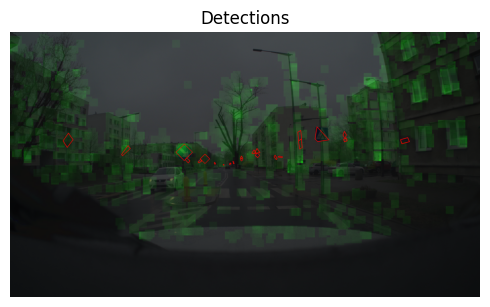

In [9]:
photos = [3, 4, 11, 13, 14]
for i in photos:
    test_image = classifier.load_test_image(i)
    result_sk = classifier.visualize_predictions(test_image, stride=16, show_ground_truth=True, score_threshold=0.5)
    plot_images([result_sk], titles=['Detections'], grid_shape=(1, 1), figsize=(5, 7))

In [10]:

classifier_custom = HOGClassifier(
    data_path='images/bt3/hog',
    train_ratio=0.8,
    patch_size=(64, 64),
    hog_method=HOGMethod.CUSTOM,
    random_seed=42,
)

In [11]:

n_train_c, n_test_c = classifier_custom.load_and_split()
print(f"Training images: {n_train_c}, Test images: {n_test_c}")

Training images: 1600, Test images: 401


In [12]:
train_metrics_custom = classifier_custom.train(
    auto_balance_negatives=True,
    balance_ratio=1.0,
    force_retrain=False,
)

Loading image from images/bt3/hog/000795/camera_front_blur/000795_india_2021-04-17T10:44:01.107098Z.jpg
Loading image from images/bt3/hog/001792/camera_front_blur/001792_india_2021-05-04T15:49:12.772107Z.jpg
Loading image from images/bt3/hog/000478/camera_front_blur/000478_golf_2021-04-27T11:30:25.107248Z.jpg
Loading image from images/bt3/hog/000807/camera_front_blur/000807_golf_2021-04-27T09:09:19.105551Z.jpg
Loading image from images/bt3/hog/001614/camera_front_blur/001614_india_2021-04-29T14:04:25.447997Z.jpg
Loading image from images/bt3/hog/001787/camera_front_blur/001787_india_2021-04-20T06:55:29.777095Z.jpg
Loading image from images/bt3/hog/001805/camera_front_blur/001805_india_2021-04-18T17:16:42.665231Z.jpg
Loading image from images/bt3/hog/001433/camera_front_blur/001433_india_2021-04-18T16:16:42.337292Z.jpg
Loading image from images/bt3/hog/000083/camera_front_blur/000083_india_2021-04-29T13:12:06.226118Z.jpg
Loading image from images/bt3/hog/001957/camera_front_blur/001957_

In [13]:
print(f"Acc: {train_metrics_custom.accuracy:.3f}, F1: {train_metrics_custom.f1:.3f}")
print(f"Recall: {train_metrics_custom.recall:.3f}, Precision: {train_metrics_custom.precision:.3f}")

Acc: 0.837, F1: 0.799
Recall: 0.752, Precision: 0.853


In [28]:
eval_custom = classifier_custom.evaluate(negatives_per_image=20)

Loading image from images/bt3/hog/000164/camera_front_blur/000164_india_2021-04-14T11:39:27.995972Z.jpg
Loading image from images/bt3/hog/001040/camera_front_blur/001040_bravo_2021-06-08T19:12:55.781811Z.jpg
Loading image from images/bt3/hog/000116/camera_front_blur/000116_india_2021-04-13T12:04:08.337637Z.jpg
Loading image from images/bt3/hog/000322/camera_front_blur/000322_golf_2021-04-24T07:19:33.224542Z.jpg
Loading image from images/bt3/hog/001087/camera_front_blur/001087_india_2021-04-29T08:10:21.776727Z.jpg
Loading image from images/bt3/hog/001029/camera_front_blur/001029_golf_2021-04-27T11:03:25.113643Z.jpg
Loading image from images/bt3/hog/000976/camera_front_blur/000976_india_2021-04-18T15:53:12.447429Z.jpg
Loading image from images/bt3/hog/001196/camera_front_blur/001196_golf_2021-05-04T16:21:32.221824Z.jpg
Loading image from images/bt3/hog/000102/camera_front_blur/000102_golf_2021-04-28T17:53:28.549948Z.jpg
Loading image from images/bt3/hog/000117/camera_front_blur/000117_in

In [29]:
print(f"\n=== Patch Classification Metrics ===")
print(f"Accuracy:  {eval_custom.accuracy:.4f}")
print(f"Precision: {eval_custom.precision:.4f}")
print(f"Recall:    {eval_custom.recall:.4f}")
print(f"F1-Score:  {eval_custom.f1:.4f}")


=== Patch Classification Metrics ===
Accuracy:  0.8139
Precision: 0.9464
Recall:    0.7714
F1-Score:  0.8500


In [14]:
detection_metrics_custom = classifier_custom.evaluate_detections(
    stride=16,
    score_threshold=0.5,
    intersection_threshold=0.3,
    max_images=25,
    n_jobs=5,
)

Loading image from images/bt3/hog/001813/camera_front_blur/001813_india_2021-05-02T08:06:58.217252Z.jpg
Loading image from images/bt3/hog/001672/camera_front_blur/001672_india_2020-10-30T06:35:37.002863Z.jpg
Loading image from images/bt3/hog/000947/camera_front_blur/000947_india_2021-04-29T10:57:16.883844Z.jpg
Loading image from images/bt3/hog/000476/camera_front_blur/000476_india_2021-04-14T11:56:38.446723Z.jpg
Loading image from images/bt3/hog/000433/camera_front_blur/000433_golf_2021-04-28T17:54:21.550969Z.jpg
Loading image from images/bt3/hog/000247/camera_front_blur/000247_golf_2021-04-27T10:58:38.108810Z.jpg
Loading image from images/bt3/hog/000014/camera_front_blur/000014_india_2021-04-18T15:57:58.885517Z.jpg
Loading image from images/bt3/hog/000824/camera_front_blur/000824_golf_2021-04-27T10:55:57.772789Z.jpg
Loading image from images/bt3/hog/001232/camera_front_blur/001232_india_2021-04-24T11:03:32.888200Z.jpg
Loading image from images/bt3/hog/000200/camera_front_blur/000200_i

In [15]:
print(f"\n=== Detection Metrics ===")
print(f"TP: {detection_metrics_custom.true_positives}, FP: {detection_metrics_custom.false_positives}")
print(f"TN: {detection_metrics_custom.true_negatives}, FN: {detection_metrics_custom.false_negatives}")
print(f"")
print(f"Hit Rate:    {detection_metrics_custom.hit_rate:.4f} (% correct)")
print(f"GT Coverage: {detection_metrics_custom.gt_coverage:.4f} (% of GTs found)")
print(f"Precision:   {detection_metrics_custom.precision:.4f}")
print(f"Recall:      {detection_metrics_custom.recall:.4f}")
print(f"F1:          {detection_metrics_custom.f1:.4f}")
print(f"")
print(f"GTs: {detection_metrics_custom.num_gt_detected}/{detection_metrics_custom.num_ground_truth}")
print(f"Windows: {detection_metrics_custom.num_detections}/{detection_metrics_custom.num_windows} positive")


=== Detection Metrics ===
TP: 640, FP: 17873
TN: 758795, FN: 4792

Hit Rate:    0.9710 (% correct)
GT Coverage: 0.0712 (% of GTs found)
Precision:   0.0346
Recall:      0.1178
F1:          0.0535

GTs: 79/1110
Windows: 18513/782100 positive


Loading image from images/bt3/hog/000322/camera_front_blur/000322_golf_2021-04-24T07:19:33.224542Z.jpg


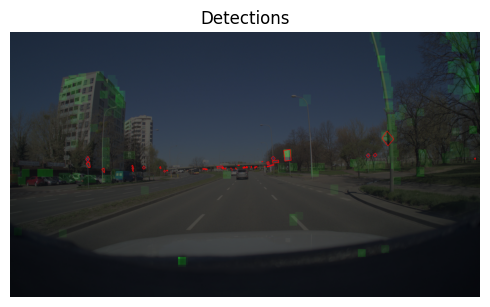

Loading image from images/bt3/hog/001087/camera_front_blur/001087_india_2021-04-29T08:10:21.776727Z.jpg


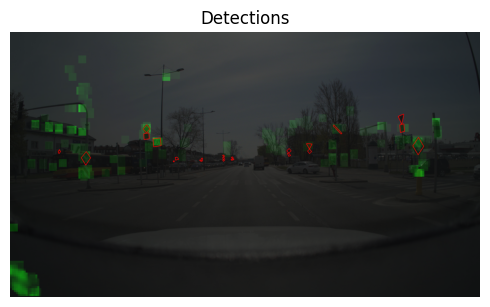

Loading image from images/bt3/hog/001531/camera_front_blur/001531_golf_2021-10-11T17:56:35.217183Z.jpg


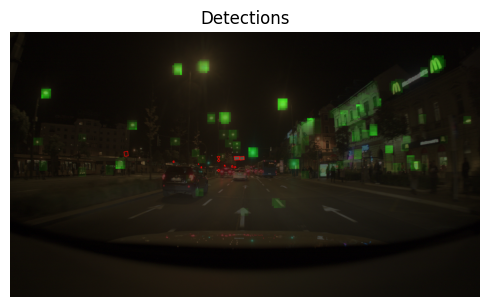

Loading image from images/bt3/hog/001110/camera_front_blur/001110_india_2021-05-01T07:54:06.886991Z.jpg


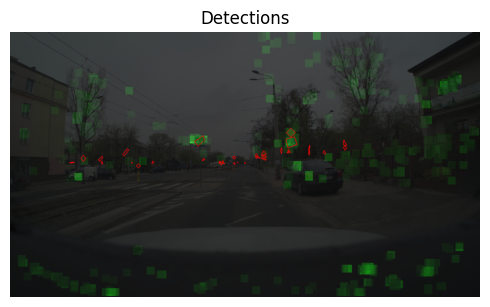

Loading image from images/bt3/hog/001506/camera_front_blur/001506_india_2021-04-15T13:39:43.777397Z.jpg


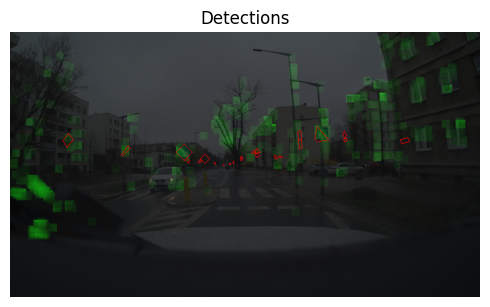

In [16]:
photos = [3, 4, 11, 13, 14]
for i in photos:
    test_image_custom = classifier_custom.load_test_image(i)
    result_custom = classifier_custom.visualize_predictions(test_image_custom, stride=16, show_ground_truth=True, score_threshold=0.5)
    plot_images([result_custom], titles=['Detections'], grid_shape=(1, 1), figsize=(5, 7))

In [17]:
def preprocess(image):
    processor = ImageProcessor().add_into_hsv_channels().add_channel_weight('H', 'S', 0.75)
    return processor.process(image)

In [18]:
pre_classifier = HOGClassifier('images/bt3/hog', hog_method=HOGMethod.SKIMAGE, preprocess_fn=preprocess, random_seed=42)

In [19]:
n_train_p, n_test_p = pre_classifier.load_and_split()
print(f"Training images: {n_train_p}, Test images: {n_test_p}")

Training images: 1600, Test images: 401


In [20]:
train_metrics_pre = pre_classifier.train(
    auto_balance_negatives=True,
    balance_ratio=1.0,
    force_retrain=False,
)

Loading image from images/bt3/hog/000795/camera_front_blur/000795_india_2021-04-17T10:44:01.107098Z.jpg
Loading image from images/bt3/hog/001792/camera_front_blur/001792_india_2021-05-04T15:49:12.772107Z.jpg
Loading image from images/bt3/hog/000478/camera_front_blur/000478_golf_2021-04-27T11:30:25.107248Z.jpg
Loading image from images/bt3/hog/000807/camera_front_blur/000807_golf_2021-04-27T09:09:19.105551Z.jpg
Loading image from images/bt3/hog/001614/camera_front_blur/001614_india_2021-04-29T14:04:25.447997Z.jpg
Loading image from images/bt3/hog/001787/camera_front_blur/001787_india_2021-04-20T06:55:29.777095Z.jpg
Loading image from images/bt3/hog/001805/camera_front_blur/001805_india_2021-04-18T17:16:42.665231Z.jpg
Loading image from images/bt3/hog/001433/camera_front_blur/001433_india_2021-04-18T16:16:42.337292Z.jpg
Loading image from images/bt3/hog/000083/camera_front_blur/000083_india_2021-04-29T13:12:06.226118Z.jpg
Loading image from images/bt3/hog/001957/camera_front_blur/001957_

In [21]:
print(f"Acc: {train_metrics_pre.accuracy:.3f}, F1: {train_metrics_pre.f1:.3f}")
print(f"Recall: {train_metrics_pre.recall:.3f}, Precision: {train_metrics_pre.precision:.3f}")

Acc: 0.803, F1: 0.764
Recall: 0.737, Precision: 0.793


In [22]:
eval_pre = pre_classifier.evaluate(negatives_per_image=20)

Loading image from images/bt3/hog/000164/camera_front_blur/000164_india_2021-04-14T11:39:27.995972Z.jpg
Loading image from images/bt3/hog/001040/camera_front_blur/001040_bravo_2021-06-08T19:12:55.781811Z.jpg
Loading image from images/bt3/hog/000116/camera_front_blur/000116_india_2021-04-13T12:04:08.337637Z.jpg
Loading image from images/bt3/hog/000322/camera_front_blur/000322_golf_2021-04-24T07:19:33.224542Z.jpg
Loading image from images/bt3/hog/001087/camera_front_blur/001087_india_2021-04-29T08:10:21.776727Z.jpg
Loading image from images/bt3/hog/001029/camera_front_blur/001029_golf_2021-04-27T11:03:25.113643Z.jpg
Loading image from images/bt3/hog/000976/camera_front_blur/000976_india_2021-04-18T15:53:12.447429Z.jpg
Loading image from images/bt3/hog/001196/camera_front_blur/001196_golf_2021-05-04T16:21:32.221824Z.jpg
Loading image from images/bt3/hog/000102/camera_front_blur/000102_golf_2021-04-28T17:53:28.549948Z.jpg
Loading image from images/bt3/hog/000117/camera_front_blur/000117_in

In [23]:
print(f"\n=== Patch Classification Metrics ===")
print(f"Accuracy:  {eval_pre.accuracy:.4f}")
print(f"Precision: {eval_pre.precision:.4f}")
print(f"Recall:    {eval_pre.recall:.4f}")
print(f"F1-Score:  {eval_pre.f1:.4f}")


=== Patch Classification Metrics ===
Accuracy:  0.7721
Precision: 0.9131
Recall:    0.7367
F1-Score:  0.8155


In [ ]:
detection_metrics_pre = pre_classifier.evaluate_detections(
    stride=16,
    score_threshold=-0.3,
    intersection_threshold=0.3,
    max_images=25,
    n_jobs=5,
)

Loading image from images/bt3/hog/001813/camera_front_blur/001813_india_2021-05-02T08:06:58.217252Z.jpg
Loading image from images/bt3/hog/000433/camera_front_blur/000433_golf_2021-04-28T17:54:21.550969Z.jpg
Loading image from images/bt3/hog/000476/camera_front_blur/000476_india_2021-04-14T11:56:38.446723Z.jpg
Loading image from images/bt3/hog/000947/camera_front_blur/000947_india_2021-04-29T10:57:16.883844Z.jpg
Loading image from images/bt3/hog/001672/camera_front_blur/001672_india_2020-10-30T06:35:37.002863Z.jpg
Loading image from images/bt3/hog/000247/camera_front_blur/000247_golf_2021-04-27T10:58:38.108810Z.jpg
Loading image from images/bt3/hog/000014/camera_front_blur/000014_india_2021-04-18T15:57:58.885517Z.jpg
Loading image from images/bt3/hog/000824/camera_front_blur/000824_golf_2021-04-27T10:55:57.772789Z.jpg
Loading image from images/bt3/hog/001232/camera_front_blur/001232_india_2021-04-24T11:03:32.888200Z.jpg
Loading image from images/bt3/hog/000200/camera_front_blur/000200_i

In [25]:
print(f"\n=== Detection Metrics ===")
print(f"TP: {detection_metrics_pre.true_positives}, FP: {detection_metrics_pre.false_positives}")
print(f"TN: {detection_metrics_pre.true_negatives}, FN: {detection_metrics_pre.false_negatives}")
print(f"")
print(f"Hit Rate:    {detection_metrics_pre.hit_rate:.4f} (% correct)")
print(f"GT Coverage: {detection_metrics_pre.gt_coverage:.4f} (% of GTs found)")
print(f"Precision:   {detection_metrics_pre.precision:.4f}")
print(f"Recall:      {detection_metrics_pre.recall:.4f}")
print(f"F1:          {detection_metrics_pre.f1:.4f}")
print(f"")
print(f"GTs: {detection_metrics_pre.num_gt_detected}/{detection_metrics_pre.num_ground_truth}")
print(f"Windows: {detection_metrics_pre.num_detections}/{detection_metrics_pre.num_windows} positive")


=== Detection Metrics ===
TP: 3527, FP: 215295
TN: 561373, FN: 1905

Hit Rate:    0.7223 (% correct)
GT Coverage: 0.1243 (% of GTs found)
Precision:   0.0161
Recall:      0.6493
F1:          0.0315

GTs: 138/1110
Windows: 218822/782100 positive


Loading image from images/bt3/hog/000322/camera_front_blur/000322_golf_2021-04-24T07:19:33.224542Z.jpg


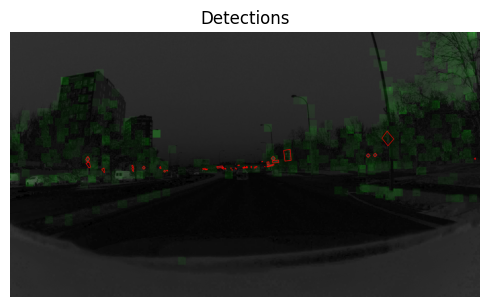

Loading image from images/bt3/hog/001087/camera_front_blur/001087_india_2021-04-29T08:10:21.776727Z.jpg


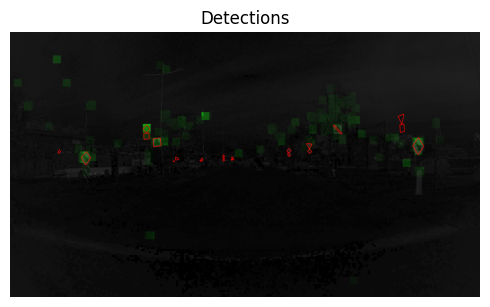

Loading image from images/bt3/hog/001531/camera_front_blur/001531_golf_2021-10-11T17:56:35.217183Z.jpg


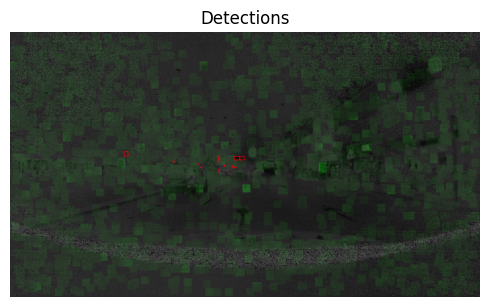

Loading image from images/bt3/hog/001110/camera_front_blur/001110_india_2021-05-01T07:54:06.886991Z.jpg


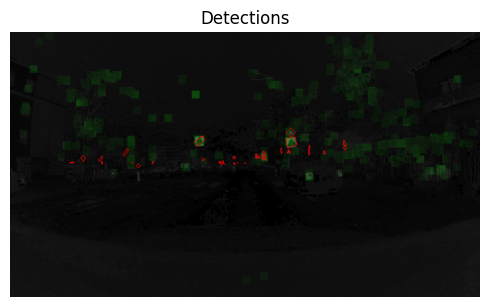

Loading image from images/bt3/hog/001506/camera_front_blur/001506_india_2021-04-15T13:39:43.777397Z.jpg


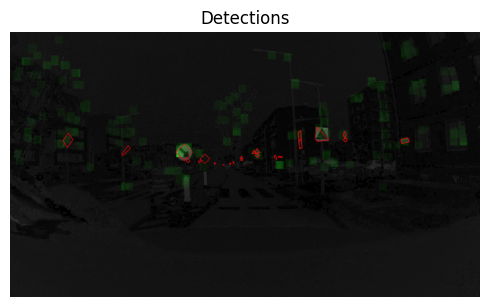

In [27]:
for i in photos:
    test_image_pre = pre_classifier.load_test_image(i)
    result_pre = pre_classifier.visualize_predictions(test_image_pre, stride=16, show_ground_truth=True, score_threshold=0.5)
    plot_images([result_pre], titles=['Detections'], grid_shape=(1, 1), figsize=(5, 7))